In [2]:
# J'installe mes bibliothèques
from curl_cffi import requests
from bs4 import BeautifulSoup
import pandas as pd

In [3]:
page = 1

# Je récupère les 5 premières pages
for i in range (1, 6):
    url = f'https://www.chucknorrisfacts.fr/facts/top/{i}'
    print(url)



# Je récupere les infos grace au .get()
response = requests.get(url, impersonate="chrome")

# Falcutatif : la gestion d'erreur
if response.status_code == 200:
    html = BeautifulSoup(response.text)
    print("Scraping effectué avec succès, le response code est 200")
else:
    print(f"Erreur lors du scraping : {response.status_code}")


https://www.chucknorrisfacts.fr/facts/top/1
https://www.chucknorrisfacts.fr/facts/top/2
https://www.chucknorrisfacts.fr/facts/top/3
https://www.chucknorrisfacts.fr/facts/top/4
https://www.chucknorrisfacts.fr/facts/top/5
Scraping effectué avec succès, le response code est 200


In [4]:
# Je scrape les facts et les notes des 5 premières pages

def get_blague_note(url):
    # Je crée une liste vide qui va contenir les blagues et les notes
    liste_blague = []
    # Je récupère les 5 premières pages
    for page in range (1, 6):
        url = f'https://www.chucknorrisfacts.fr/facts/top/{page}'
        response = requests.get(url, impersonate="chrome")
        html = BeautifulSoup(response.text, 'html.parser')
        # Je récupère les divs qui contiennent les blagues et les notes
        divs = html.find_all('div', class_='card')
 
    # Je remplis mon dictionnaire avec les blagues et les notes
        for i in divs : # Je parcours les divs qui contiennent les blagues et les notes
            row = i.find("div", class_="row")   # Je crée une variable row qui permet de vérifier si il y a bien une valeur dans la div
            # Si il y a une valeur dans la div, alors je remplis mon dictionnaire avec la blague et la note
            if row : 
                dico = {"Blague" : i.find("p", class_="card-text").get_text(), "Note" : row.find("span").get_text()}
                liste_blague.append(dico)

    return liste_blague
            

In [5]:
# Je crée une variable link qui contient l'url de la page que je veux scraper
link =  f'https://www.chucknorrisfacts.fr/facts/top/{page}'

# J'appelle ma fonction get_blague_note() et je stocke le résultat dans une variable liste_blague_5
liste_blague_5 = get_blague_note(link)

# Je crée un dataframe à partir de ma liste de blagues et de notes
df = pd.DataFrame(liste_blague_5)
df.info() # J'ai bien 100 lignes

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Blague  100 non-null    str  
 1   Note    100 non-null    str  
dtypes: str(2)
memory usage: 1.7 KB


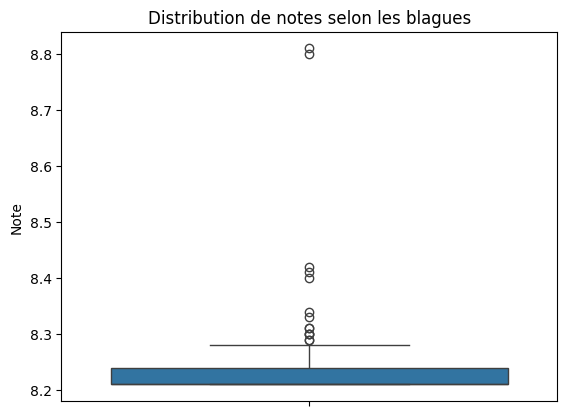

In [6]:
# Je crée une visualisation de mon dataframe avec un graphique en barres qui montre la répartition des notes
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re

# On extrait le nombre entre "(" et "/"
df['Note'] = df['Note'].str.extract(r'\((\d+\.\d+)').astype(float) # J'extrais avec regex le premier chiffre "8", puis le "." puis l'autre chiffre après le point (le décimal) et je convertis en float avec astype()

# sns_boxplot : Visualise la distribution + outliers
sns.boxplot(data=df, y='Note')
plt.title('Distribution de notes selon les blagues')
plt.show()